# Stadt Zurich Birth Analysis

## Data Set

Births by city district, age of mother, sex of child, origin of mother and child 

**Time frame**: 1993 – 2025

**Size**: 66.5k+ rows x 9 columns


## 0. Start

### Initialize

In [ ]:
import pandas as pd 
import numpy as np

df = pd.read_csv("raw_data.csv")

# printing out basic details to get an initial idea 
print(df.head())
print(df.shape)
print(df.dtypes)
print(df.columns)

   EreignisDatJahr  QuarCd QuarLang  AlterVMutterCd  SexCd  HerkunftCd  \
0             1993      11  Rathaus              19      2           1   
1             1993      11  Rathaus              21      1           2   
2             1993      11  Rathaus              21      2           2   
3             1993      11  Rathaus              22      1           2   
4             1993      11  Rathaus              27      2           1   

   HerkunftMutterCd LebensfaehigkeitCd  AnzGebuWir  
0                 1                  J           1  
1                 2                  J           1  
2                 2                  J           1  
3                 2                  J           1  
4                 1                  J           2  
(66574, 9)
EreignisDatJahr       int64
QuarCd                int64
QuarLang                str
AlterVMutterCd        int64
SexCd                 int64
HerkunftCd            int64
HerkunftMutterCd      int64
LebensfaehigkeitCd      str
An

### Translating Column Headers from German to English 

Creating a new "English" data frame, to keep the original untouched. 

In [118]:
eng_df = df.rename(columns={"EreignisDatJahr": "year", 
                    "QuarCd": "district_code", 
                    "QuarLang": "district_name", 
                    "AlterVMutterCd": "mother_age",
                    "SexCd": "child_sex",
                    "HerkunftCd": "child_origin",
                    "HerkunftMutterCd": "mother_origin",
                    "LebensfaehigkeitCd": "viability",
                    "AnzGebuWir": "births"})

# check for updates
print(eng_df.head())

   year  district_code district_name  mother_age  child_sex  child_origin  \
0  1993             11       Rathaus          19          2             1   
1  1993             11       Rathaus          21          1             2   
2  1993             11       Rathaus          21          2             2   
3  1993             11       Rathaus          22          1             2   
4  1993             11       Rathaus          27          2             1   

   mother_origin viability  births  
0              1         J       1  
1              2         J       1  
2              2         J       1  
3              2         J       1  
4              1         J       2  


### Omit unnecessary data 

In [119]:
print(eng_df["viability"].unique()) 

<StringArray>
['J']
Length: 1, dtype: str


For the viability column, the unique values are only 1, which is "J". 

All cell entries under this column are J, which is german for ja, which means yes. 

This happens because this specific data set only looks at live births. Therefore, we can safely omit the viability column for the analysis. 

In [120]:
eng_df = eng_df.drop(columns=["viability"])
print(eng_df)

       year  district_code district_name  mother_age  child_sex  child_origin  \
0      1993             11       Rathaus          19          2             1   
1      1993             11       Rathaus          21          1             2   
2      1993             11       Rathaus          21          2             2   
3      1993             11       Rathaus          22          1             2   
4      1993             11       Rathaus          27          2             1   
...     ...            ...           ...         ...        ...           ...   
66569  2025            123    Hirzenbach          42          1             1   
66570  2025            123    Hirzenbach          43          1             1   
66571  2025            123    Hirzenbach          43          2             2   
66572  2025            123    Hirzenbach          44          1             1   
66573  2025            123    Hirzenbach          44          2             2   

       mother_origin  birth

### Mapping Labels to Numeric Codes for Mother's Origin, Child's Origin and Child's Sex Columns 

Data source website of Stadt Zurich says the codes are store as strings, which explains the maps below. 

In [121]:
# origin of child and mother 
origin_map = {1: "Swiss", 2: "Foreign"}
eng_df["child_origin"] = eng_df["child_origin"].map(origin_map)
eng_df["mother_origin"] = eng_df["mother_origin"].map(origin_map)

# sex of child 
sex_map = {1: "Male", 2: "Female"}
eng_df["child_sex"] = eng_df["child_sex"].map(sex_map)

print(eng_df)

       year  district_code district_name  mother_age child_sex child_origin  \
0      1993             11       Rathaus          19    Female        Swiss   
1      1993             11       Rathaus          21      Male      Foreign   
2      1993             11       Rathaus          21    Female      Foreign   
3      1993             11       Rathaus          22      Male      Foreign   
4      1993             11       Rathaus          27    Female        Swiss   
...     ...            ...           ...         ...       ...          ...   
66569  2025            123    Hirzenbach          42      Male        Swiss   
66570  2025            123    Hirzenbach          43      Male        Swiss   
66571  2025            123    Hirzenbach          43    Female      Foreign   
66572  2025            123    Hirzenbach          44      Male        Swiss   
66573  2025            123    Hirzenbach          44    Female      Foreign   

      mother_origin  births  
0             Swiss  

### Final Tests Before Exporting CSVs for Defined Analysis DataFrames 

In [122]:
print(eng_df["mother_age"].unique()) 

[ 19  21  22  27  29  30  31  33  34  35  36  37  39  40  41  43  18  26
  32  42  20  23  24  25  28  38  17  44  47  16  15  45  46  49  48  50
  14  52  51 999  56  54   0  57  53  55]


There is a/multiple value(s) of age 0. That is means the mother chose not to disclose her age. To avoid any skews in data, we will delete these outliers at a later stage. 

## 1. Analysis Points 

### **Demographic overview**

1. Total births per year 1993-2025 

2. Births by child sex per year 

3. Swiss vs foreign-origin births over time 


### **District/geographic**

4. Total births by district over all years 

5. Births by district over time 

6. Year-on-year percentage change by district 


### **Maternal age**

7. Average maternal age per year 

8. Distribution of births by age group per year 


### **Cross-dimensional**

9. Foreign-origin mothers by district 

10. Maternal age by origin group over time 


For every analysis point, I first prepare the data for export by selecting the relevant columns and perform any calculations, if needed. I then create rough visualizations using Matplotlib library to ensure that my data is appearing correctly. 

In [123]:
import matplotlib.pyplot as plt

clean_df = eng_df.copy(deep=True)
clean_df["mother_age"] = clean_df["mother_age"].replace([0, 999], np.nan) 

### 1. Total births per year 1993-2025 

Columns under consideration: year, births 

In [124]:
result_1 = clean_df.groupby("year")["births"].sum()

print(result_1)

year
1993    3400
1994    3483
1995    3419
1996    3430
1997    3459
1998    3455
1999    3489
2000    3577
2001    3472
2002    3553
2003    3629
2004    3791
2005    3895
2006    4029
2007    4119
2008    4349
2009    4639
2010    4588
2011    4760
2012    4678
2013    4920
2014    5145
2015    5191
2016    5176
2017    5240
2018    5212
2019    5134
2020    5133
2021    5261
2022    4538
2023    4475
2024    4345
2025    4535
Name: births, dtype: int64


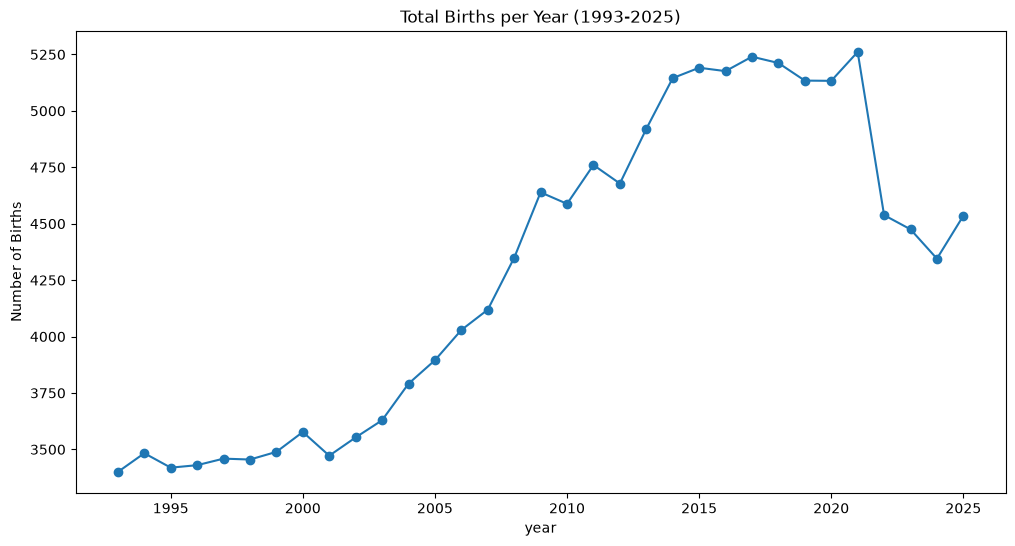

In [125]:
plt.figure(figsize=(12, 6))
result_1.plot(kind='line', marker='o')
plt.title("Total Births per Year (1993-2025)")
plt.ylabel("Number of Births")
plt.show()

### 2. Births by child sex per year 

Columns under consideration: year, child_sex, births 

In [126]:
result_2 = clean_df.groupby(["year", "child_sex"])["births"].sum().unstack()

print(result_2)

child_sex  Female  Male
year                   
1993         1691  1709
1994         1717  1766
1995         1652  1767
1996         1622  1808
1997         1621  1838
1998         1696  1759
1999         1655  1834
2000         1681  1896
2001         1736  1736
2002         1738  1815
2003         1731  1898
2004         1859  1932
2005         1890  2005
2006         1975  2054
2007         2008  2111
2008         2101  2248
2009         2244  2395
2010         2240  2348
2011         2263  2497
2012         2255  2423
2013         2434  2486
2014         2549  2596
2015         2478  2713
2016         2462  2714
2017         2543  2697
2018         2526  2686
2019         2544  2590
2020         2465  2668
2021         2586  2675
2022         2204  2334
2023         2202  2273
2024         2092  2253
2025         2211  2324


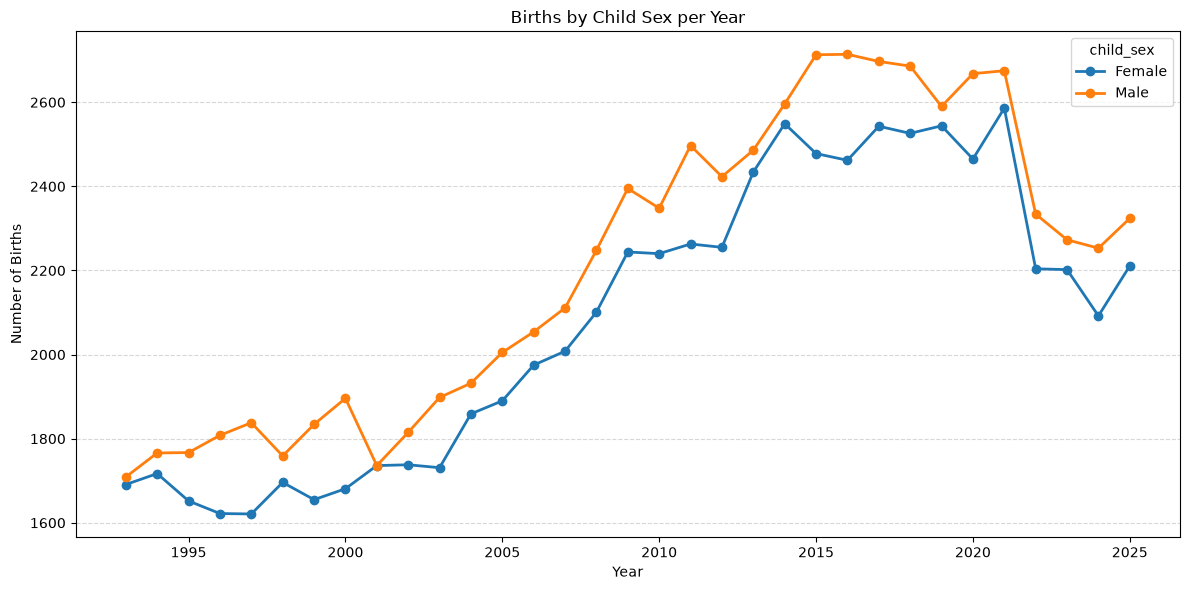

In [127]:
result_2.plot(kind='line', figsize=(12, 6), marker='o', linewidth=2)

plt.title("Births by Child Sex per Year")
plt.xlabel("Year")
plt.ylabel("Number of Births")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 3. Swiss vs foreign-origin births over time 

Columns under consideration: year, child_origin, births 

In [128]:
result_3 = clean_df.groupby(["year", "child_origin"])["births"].sum().unstack()

print(result_3)

child_origin  Foreign  Swiss
year                        
1993             1313   2087
1994             1394   2089
1995             1441   1978
1996             1470   1960
1997             1516   1943
1998             1581   1874
1999             1545   1944
2000             1550   2027
2001             1410   2062
2002             1481   2072
2003             1407   2222
2004             1421   2370
2005             1396   2499
2006             1392   2637
2007             1329   2790
2008             1380   2969
2009             1467   3172
2010             1443   3145
2011             1451   3309
2012             1539   3139
2013             1625   3295
2014             1752   3393
2015             1773   3418
2016             1688   3488
2017             1833   3407
2018             1822   3390
2019             1761   3373
2020             1683   3450
2021             1666   3595
2022             1521   3017
2023             1564   2911
2024             1515   2830
2025          

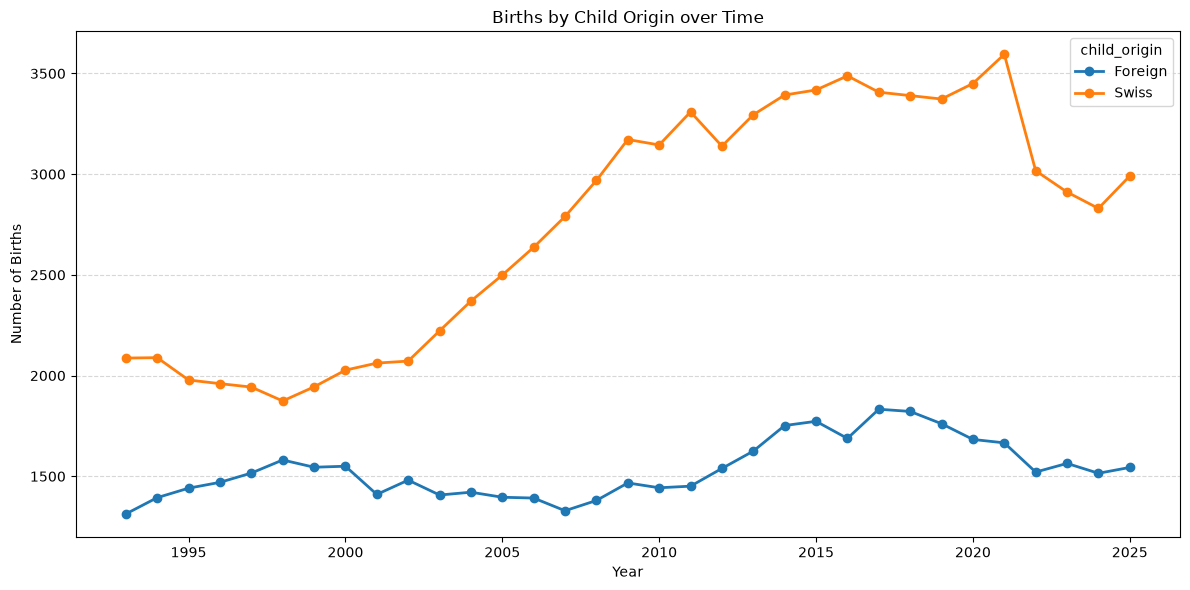

In [129]:
result_3.plot(kind='line', figsize=(12, 6), marker='o', linewidth=2)

plt.title("Births by Child Origin over Time")
plt.xlabel("Year")
plt.ylabel("Number of Births")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4. Total births by district over all years 

Columns under consideration: district_name, births 

In [130]:
result_4 = clean_df.groupby("district_name")["births"].sum().fillna(0).astype(int).sort_values(ascending=True)

print(result_4)

district_name
Hochschulen                96
City                      234
Lindenhof                 248
Rathaus                   664
Weinegg                  1619
Escher Wyss              1686
Leimbach                 1819
Mühlebach                1861
Seefeld                  1919
Werd                     1960
Hirslanden               2513
Fluntern                 2521
Saatlen                  2541
Friesenberg              2660
Witikon                  2947
Oberstrass               3395
Gewerbeschule            3521
Hottingen                3645
Langstrasse              3663
Schwamendingen-Mitte     3766
Enge                     4030
Hirzenbach               4373
Hard                     4476
Wollishofen              6136
Wipkingen                6375
Albisrieden              6758
Alt-Wiedikon             6885
Oerlikon                 7417
Höngg                    7467
Unterstrass              8176
Seebach                  8207
Affoltern                8278
Sihlfeld                 8

It is quite tedious to plot this data on a map within this Jupyter Notebook. The end goal of the project is to plot the data in Tableau, so for now I have just used a bar chart to visualize the data. 

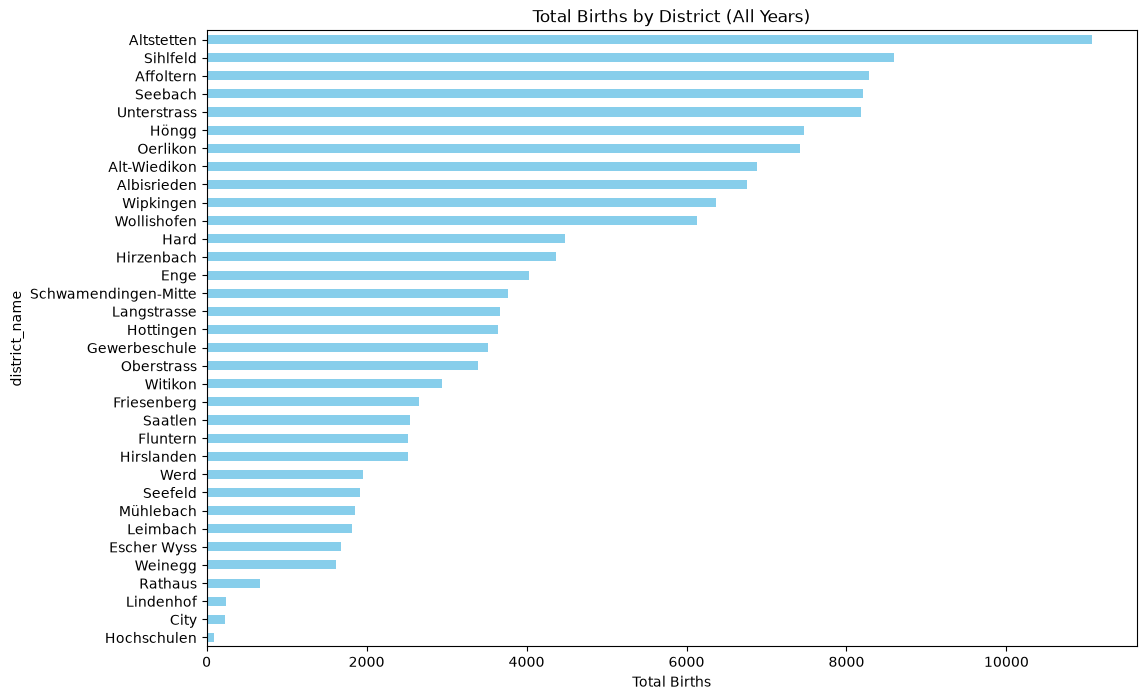

In [131]:
result_4.plot(kind='barh', figsize=(12, 8), color='skyblue')

plt.title("Total Births by District (All Years)")
plt.xlabel("Total Births")
plt.show()

### 5. Births by district over time 

Columns under consideration: year, district_name, births 

In [132]:
result_5 = clean_df.groupby(["year", "district_name"])["births"].sum().unstack().fillna(0).astype(int) 

print(result_5) 

district_name  Affoltern  Albisrieden  Alt-Wiedikon  Altstetten  City  Enge  \
year                                                                          
1993                 167          153           163         239     5    90   
1994                 162          143           182         282     6    82   
1995                 180          142           191         273    11    90   
1996                 175          143           180         273    12    91   
1997                 178          157           179         258     7    92   
1998                 188          136           173         241     6    82   
1999                 191          121           195         300     9    79   
2000                 209          135           178         296     6   100   
2001                 174          138           149         290     8    85   
2002                 195          127           143         314     7   111   
2003                 205          134           160 

Simplied version, accounting only the top 8. 

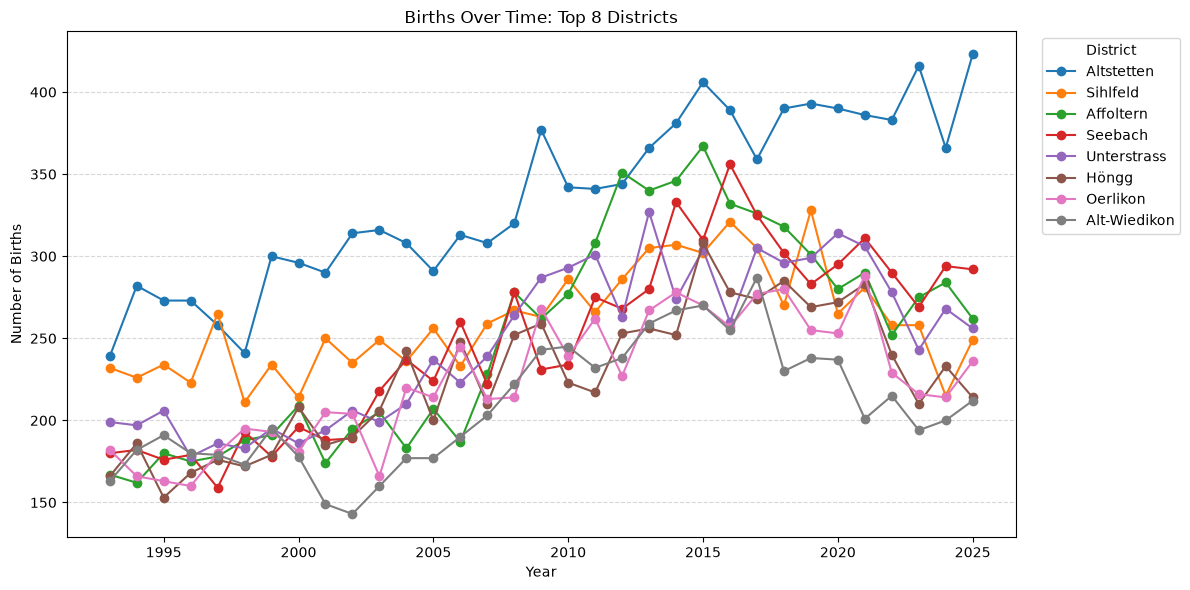

In [133]:
top8 = result_4.sort_values(ascending=False).head(8).index
result_5[top8].plot(figsize=(12, 6), marker='o', linewidth=1.5)

plt.title("Births Over Time: Top 8 Districts")
plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.legend(title="District", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 6. Year-on-year percentage change by district 

DF used: pct_change_by_district

Columns under consideration: year, district_name, births 

In [134]:
# based on analysis 4 

result_6 = (clean_df.groupby(["year", "district_name"])["births"].sum().unstack().pct_change().replace([np.inf, -np.inf], np.nan).round(2) * 100)

print(result_6)

district_name  Affoltern  Albisrieden  Alt-Wiedikon  Altstetten   City  Enge  \
year                                                                           
1993                 NaN          NaN           NaN         NaN    NaN   NaN   
1994                -3.0         -7.0          12.0        18.0   20.0  -9.0   
1995                11.0         -1.0           5.0        -3.0   83.0  10.0   
1996                -3.0          1.0          -6.0         0.0    9.0   1.0   
1997                 2.0         10.0          -1.0        -5.0  -42.0   1.0   
1998                 6.0        -13.0          -3.0        -7.0  -14.0 -11.0   
1999                 2.0        -11.0          13.0        24.0   50.0  -4.0   
2000                 9.0         12.0          -9.0        -1.0  -33.0  27.0   
2001               -17.0          2.0         -16.0        -2.0   33.0 -15.0   
2002                12.0         -8.0          -4.0         8.0  -12.0  31.0   
2003                 5.0          6.0   

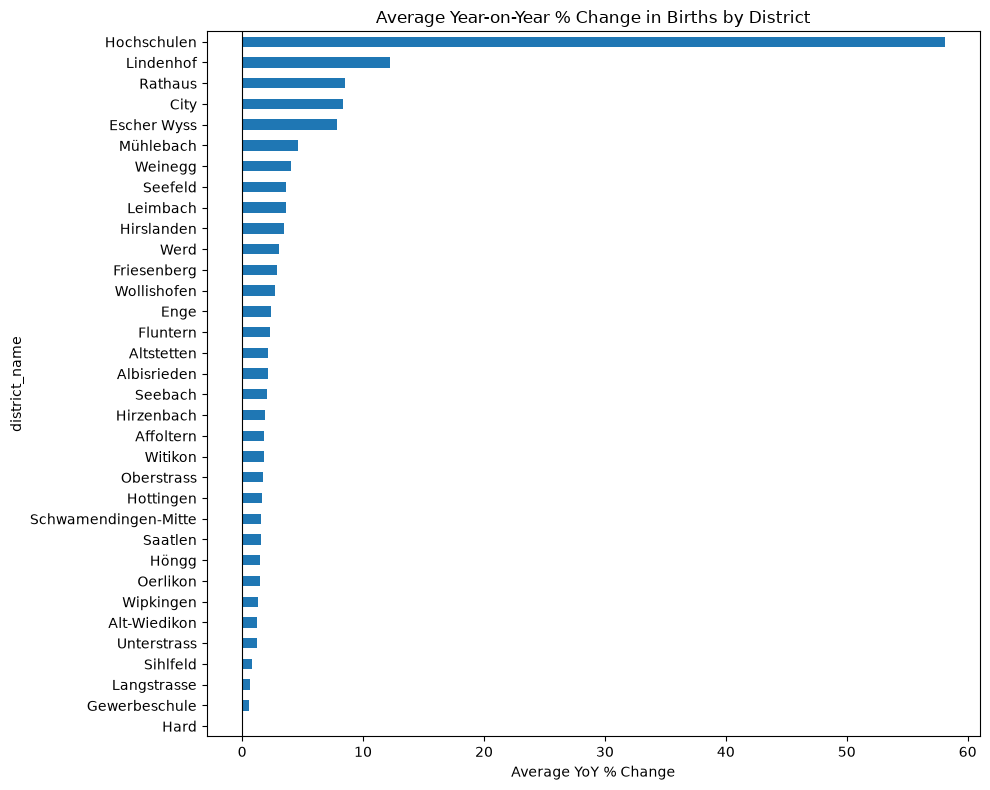

In [135]:
avg_yoy = result_6.mean().sort_values()
avg_yoy.plot(kind='barh', figsize=(10, 8))

plt.title("Average Year-on-Year % Change in Births by District")
plt.xlabel("Average YoY % Change")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 7. Average maternal age per year 

DF used: avg_age_per_year

Columns under consideration: year, mother_age, births 

In [149]:
age_data = clean_df.dropna(subset=["mother_age"]).copy()
age_data["age_x_births"] = age_data["mother_age"] * age_data["births"]

grouped = age_data.groupby("year")[["age_x_births", "births"]].sum()
result_7 = (grouped["age_x_births"] / grouped["births"]).round(2).rename("avg maternal age").reset_index()

print(result_7) 

    year  avg maternal age
0   1993             29.41
1   1994             29.40
2   1995             29.48
3   1996             29.45
4   1997             29.74
5   1998             29.87
6   1999             29.74
7   2000             29.93
8   2001             30.24
9   2002             30.40
10  2003             30.74
11  2004             30.99
12  2005             31.20
13  2006             31.37
14  2007             31.84
15  2008             32.07
16  2009             32.14
17  2010             32.28
18  2011             32.40
19  2012             32.51
20  2013             32.69
21  2014             32.79
22  2015             32.87
23  2016             33.09
24  2017             33.22
25  2018             33.30
26  2019             33.42
27  2020             33.58
28  2021             33.70
29  2022             33.89
30  2023             33.97
31  2024             34.06
32  2025             34.21


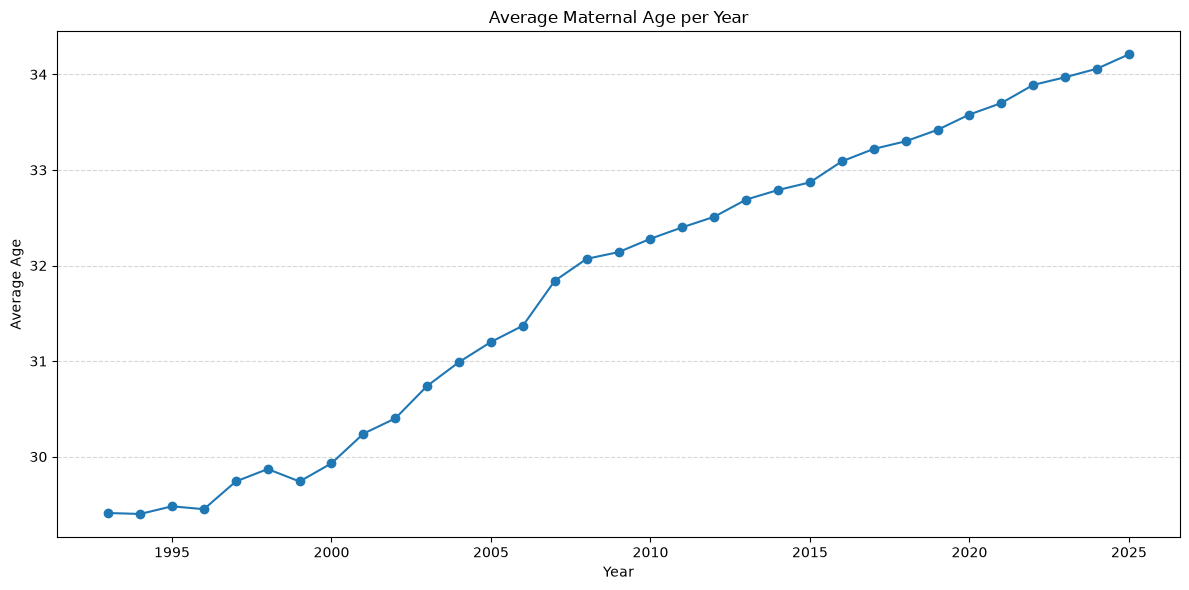

In [137]:
result_7.plot(figsize=(12, 6), marker='o')

plt.title("Average Maternal Age per Year")
plt.xlabel("Year")
plt.ylabel("Average Age")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 8. Distribution of births by age group per year 

DF used: by_age_group

Columns under consideration: year, mother_age, births 

In [138]:
bins = [0, 19, 24, 29, 34, 39, 100]
labels = ["Under 20", "20-24", "25-29", "30-34", "35-39", "40+"]

age_data = clean_df.dropna(subset=["mother_age"]).copy()
age_data["age_group"] = pd.cut(age_data["mother_age"], bins=bins, labels=labels)

result_8 = age_data.groupby(["year", "age_group"], observed=True)["births"].sum().unstack().fillna(0).astype(int)

print(result_8)

age_group  Under 20  20-24  25-29  30-34  35-39  40+
year                                                
1993             73    526   1125   1110    488   78
1994             96    542   1114   1150    492   89
1995             73    538   1099   1156    468   85
1996             87    562   1059   1114    526   82
1997             77    545   1028   1143    559  107
1998             71    547    960   1186    586  105
1999            105    561    959   1154    603  107
2000             86    556    963   1228    600  144
2001             70    527    879   1183    679  134
2002             66    507    913   1195    733  139
2003             60    501    878   1210    815  165
2004             52    454    912   1347    858  168
2005             59    403    939   1392    888  214
2006             58    418    899   1474    976  204
2007             49    374    842   1503   1092  259
2008             43    357    864   1618   1179  288
2009             48    352    905   1754   128

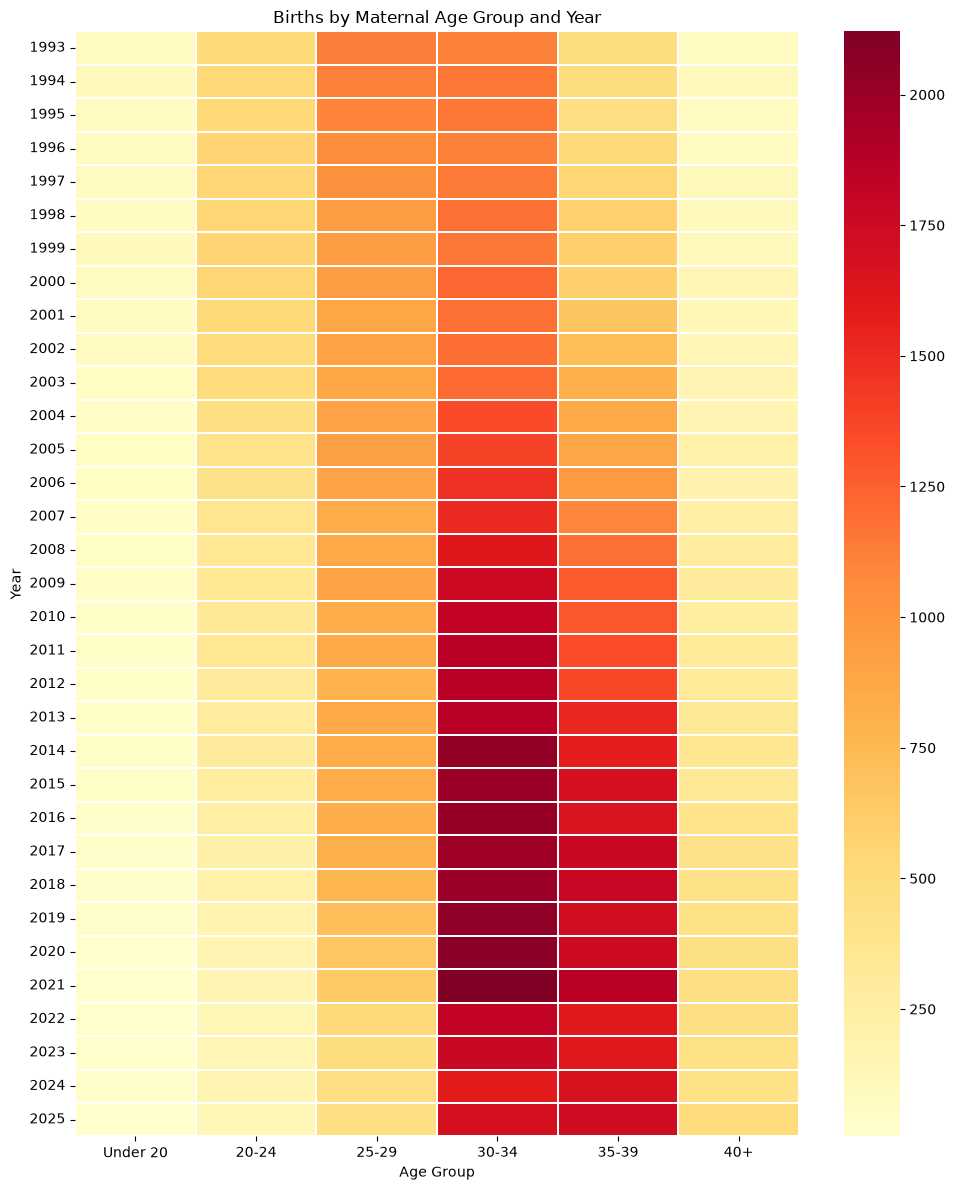

In [139]:
import seaborn as sns

plt.figure(figsize=(10, 12))
sns.heatmap(result_8, cmap='YlOrRd', linewidths=0.3)

plt.title("Births by Maternal Age Group and Year")
plt.xlabel("Age Group")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

### 9. Foreign-origin mothers by district 

Columns under consideration: district_name, mother_origin, births 

In [140]:
foreign_only = eng_df[eng_df["mother_origin"] == "Foreign"]

result_9 = foreign_only.groupby("district_name")["births"].sum().sort_values(ascending=False) 

print(result_9)

district_name
Altstetten              6277
Seebach                 4934
Affoltern               4310
Oerlikon                4132
Sihlfeld                4030
Unterstrass             3183
Alt-Wiedikon            3179
Albisrieden             2915
Höngg                   2906
Wollishofen             2798
Wipkingen               2790
Hirzenbach              2643
Hard                    2635
Schwamendingen-Mitte    2410
Langstrasse             1886
Enge                    1781
Gewerbeschule           1749
Hottingen               1432
Oberstrass              1296
Witikon                 1282
Saatlen                 1221
Fluntern                1107
Friesenberg              968
Hirslanden               951
Leimbach                 938
Seefeld                  892
Mühlebach                854
Werd                     814
Escher Wyss              778
Weinegg                  752
Rathaus                  247
City                     101
Lindenhof                 98
Hochschulen               34


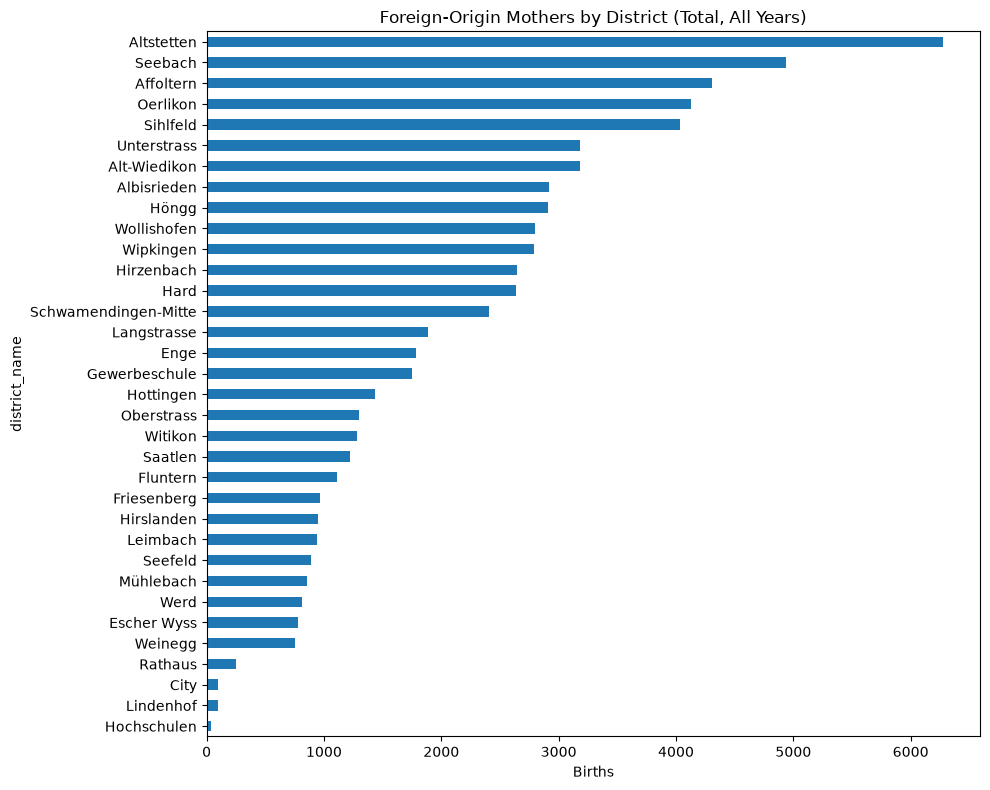

In [141]:
result_9.plot(kind='barh', figsize=(10, 8))

plt.title("Foreign-Origin Mothers by District (Total, All Years)")
plt.xlabel("Births")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 10. Maternal age by origin group over time 

Columns under consideration: year, mother_origin, mother_age, births 

In [142]:
by_origin_age = eng_df.copy(deep=True)

by_origin_age["mother_age"] = by_origin_age["mother_age"].replace([0, 999], np.nan) 
by_origin_age = by_origin_age.dropna(subset=["mother_age"]) 

by_origin_age["total_age_pool"] = by_origin_age["mother_age"] * by_origin_age["births"] 

grouped = by_origin_age.groupby(["year", "mother_origin"])[["total_age_pool", "births"]].sum() 

result_10 = (grouped["total_age_pool"] / grouped["births"]).unstack().round(2) 

print(result_10) 

mother_origin  Foreign  Swiss
year                         
1993             27.72  30.58
1994             27.63  30.80
1995             27.83  30.96
1996             27.72  31.10
1997             28.28  31.23
1998             28.49  31.44
1999             28.32  31.34
2000             28.46  31.65
2001             28.72  31.92
2002             29.17  31.80
2003             29.22  32.30
2004             29.80  32.23
2005             29.94  32.40
2006             30.29  32.37
2007             30.80  32.75
2008             31.19  32.83
2009             31.33  32.83
2010             31.61  32.84
2011             31.61  33.02
2012             31.88  33.07
2013             32.19  33.13
2014             32.42  33.13
2015             32.33  33.36
2016             32.65  33.47
2017             33.00  33.45
2018             32.99  33.60
2019             33.09  33.73
2020             33.44  33.72
2021             33.55  33.83
2022             33.64  34.13
2023             33.99  33.95
2024      

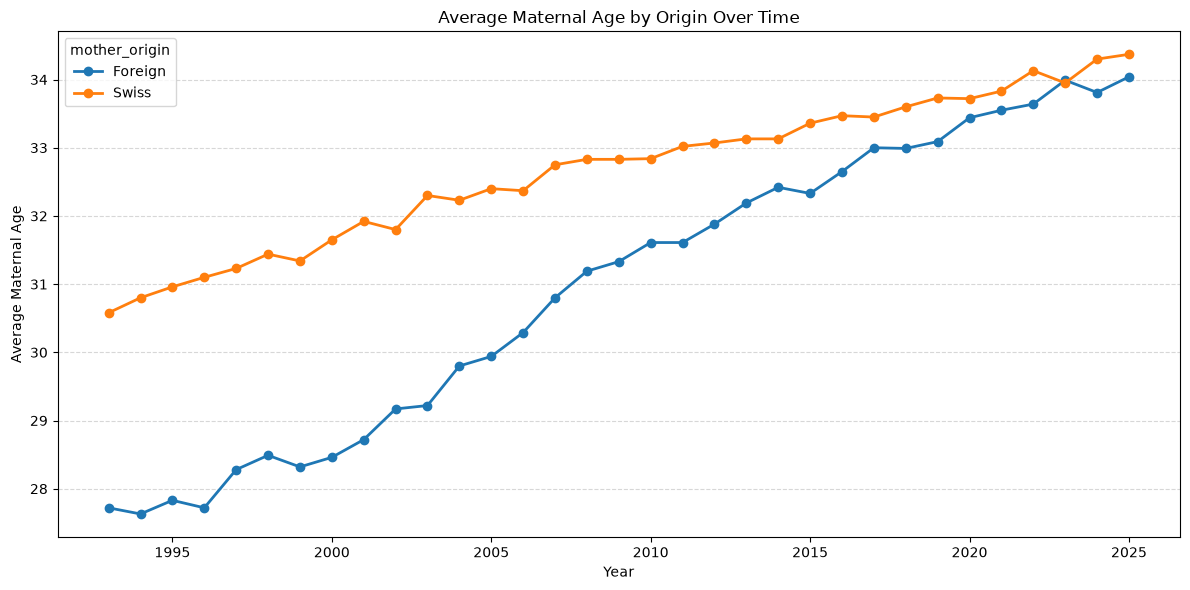

In [143]:
result_10.plot(figsize=(12, 6), marker='o', linewidth=2)

plt.title("Average Maternal Age by Origin Over Time")
plt.xlabel("Year")
plt.ylabel("Average Maternal Age")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Time to export to Tableau 

In [153]:
result_4_geo = clean_df.groupby(["district_code", "district_name"])["births"].sum().reset_index()
result_5_geo = clean_df.groupby(["year", "district_code", "district_name"])["births"].sum().reset_index() 
result_8_time = result_8.stack().reset_index() 
result_8_time.columns = ["year", "age_group", "births"] 
result_9_foreign_geo = eng_df[eng_df["mother_origin"] == "Foreign"].groupby(["district_code", "district_name"])["births"].sum().reset_index()
result_9_swiss_geo = eng_df[eng_df["mother_origin"] == "Swiss"].groupby(["district_code", "district_name"])["births"].sum().reset_index()


In [154]:
import os
os.makedirs("output", exist_ok=True)

result_1.to_csv("output/01_total_births_per_year.csv")
result_2.to_csv("output/02_births_by_sex.csv")
result_3.to_csv("output/03_births_by_child_origin.csv")
result_4_geo.to_csv("output/04_births_by_district.csv", index=False)
result_5_geo.to_csv("output/05_births_by_district_over_time.csv", index=False)
result_6.to_csv("output/06_yoy_pct_change_by_district.csv")
result_7.to_csv("output/07_avg_maternal_age_per_year.csv")
result_8_time.to_csv("output/08_births_by_age_group.csv", index=False)
result_9_foreign_geo.to_csv("output/09.1_foreign_mothers_by_district.csv", index=False)
result_9_swiss_geo.to_csv("output/09.2_swiss_mothers_by_district.csv", index=False)
result_10.to_csv("output/10_maternal_age_by_origin.csv")

print("Exported", len(os.listdir("output")), "CSVs to /output")

Exported 11 CSVs to /output
